# Q1 - Movement and Distance Analysis: Movement focused


**Author**: Jihyeon Yun


**Dataset**: 40B_zip_long_lat.csv (https://drive.google.com/file/d/1n92fRXF_BWBSz2-vAPYDsduTz93VxYul/view?usp=drive_link)


**Instruction**: Download the CSV file above and move it to the ds-chapa-affordable-housing/fa25-team-a/data folder, then run the cells below

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.patches import Patch

df = pd.read_csv("../data/40B_zip_long_lat.csv")

# Applicant Movement Pattern

In [2]:
df['distance_mi'].describe()

,distance_mi
count,1619.000000
mean,18.886330
std,72.298534
min,0.000000
25%,5.615656
50%,11.043263
75%,20.155985
max,1339.484124


Mean value of distance movement is about 18.88 miels and median value is 11.04 miles. Since the median value is smaller than mean value, we can know that the distance data is right-skewed.
To normalize this distribution, we applied a log transformation.

In [3]:
df['log_distance_mi'] = np.log1p(df['distance_mi'])
print(df['log_distance_mi'].describe())

count    1619.000000
mean        2.363798
std         1.049153
min         0.000000
25%         1.889439
50%         2.488505
75%         3.051922
max         7.200786
Name: log_distance_mi, dtype: float64


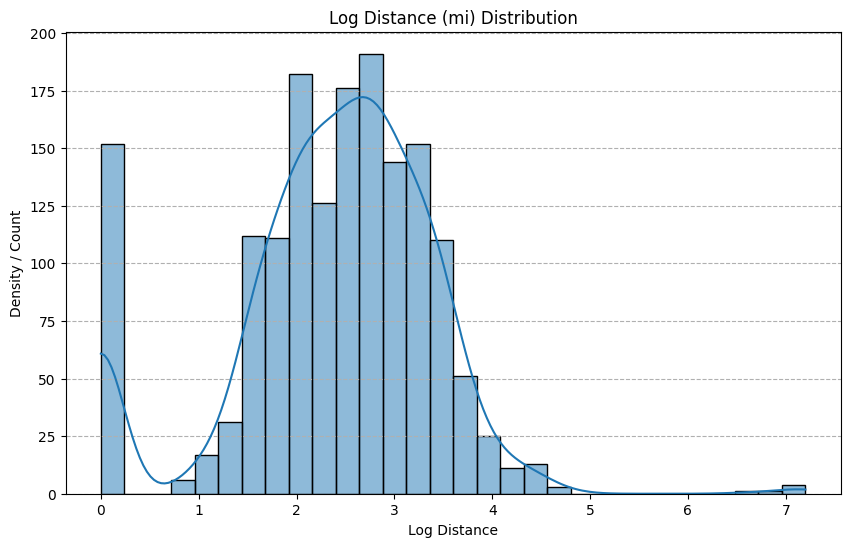

In [4]:
plt.figure(figsize=(10, 6))

sns.histplot(df['log_distance_mi'], bins=30, kde=True, edgecolor='black')

plt.title('Log Distance (mi) Distribution')
plt.xlabel('Log Distance')
plt.ylabel('Density / Count')
plt.grid(axis='y', linestyle='--')
plt.show()

No data between log 5 and 6.
There are extreme outliers we have to cut-off.

check the number of lower/upper outliers

In [5]:
# lower outliers: no movement (distance = 0)
count = 0
for i in range(len(df)):
  if df['distance_mi'][i] == 0:
    count += 1
print(count)
print((count / len(df))*100) # percentage

152
9.388511426806671


In [6]:
# according to the log transformed plot -> huge outliers after log distance=5
T_log_visual = 5
thres_log = np.expm1(T_log_visual)

count = 0
for i in range(len(df)):
  if (df['distance_mi'][i] > 0) and (df['distance_mi'][i] < thres_log):
    count += 1
print(count)
print((count / len(df))*100) # percentage

1461
90.24088943792464


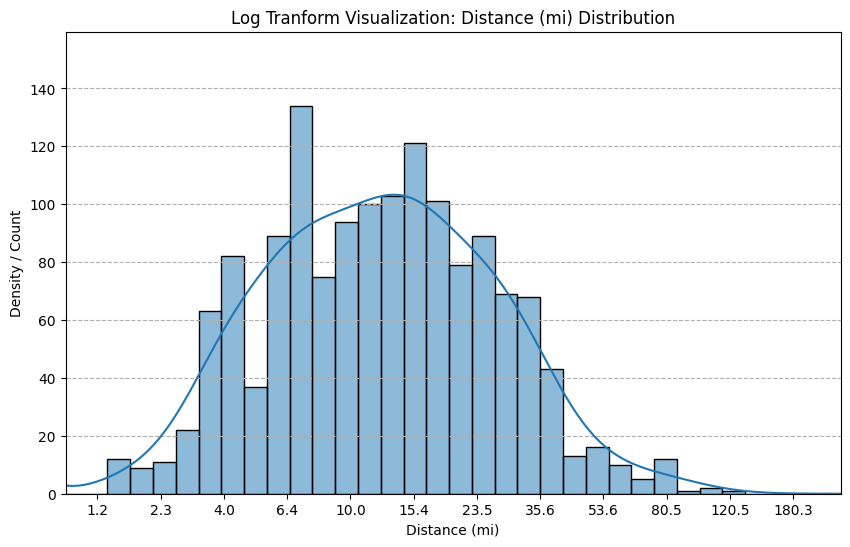

In [7]:
plt.figure(figsize=(10, 6))

sns.histplot(df['log_distance_mi'], bins=50, kde=True, edgecolor='black')
log_ticks = np.arange(0, 7, 0.4)
mile_labels = np.expm1(log_ticks)
formatted_labels = [f'{m:.1f}' for m in mile_labels]
plt.xticks(log_ticks, formatted_labels, rotation=0, ha='center')

plt.xlim(right=5.5, left=0.6)
plt.title('Log Tranform Visualization: Distance (mi) Distribution')
plt.xlabel('Distance (mi)')
plt.ylabel('Density / Count')
plt.grid(axis='y', linestyle='--')
plt.show()

still skewed on right side -> cut off some applicant to get 80%

In [8]:
T_log_visual = 3.5

T_original_miles = np.expm1(T_log_visual)
thres_log = T_original_miles
print(thres_log)

count = 0
for i in range(len(df)):
  if (df['distance_mi'][i] > 0) and (df['distance_mi'][i] < thres_log):
    count += 1
print(count)
print((count / len(df))*100) # percentage

32.11545195869231
1317
81.34651019147621


In [9]:
filtered_df = df[
    (df['distance_mi'] > 0) &
    (df['distance_mi'] < thres_log)
].copy()

filtered_df['distance_mi'].describe()

,distance_mi
count,1317.000000
mean,12.784725
std,7.730221
min,1.472946
25%,6.581904
50%,11.043263
75%,17.525538
max,31.970441


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Histogram created. Q1: 1.47, Q3: 31.97


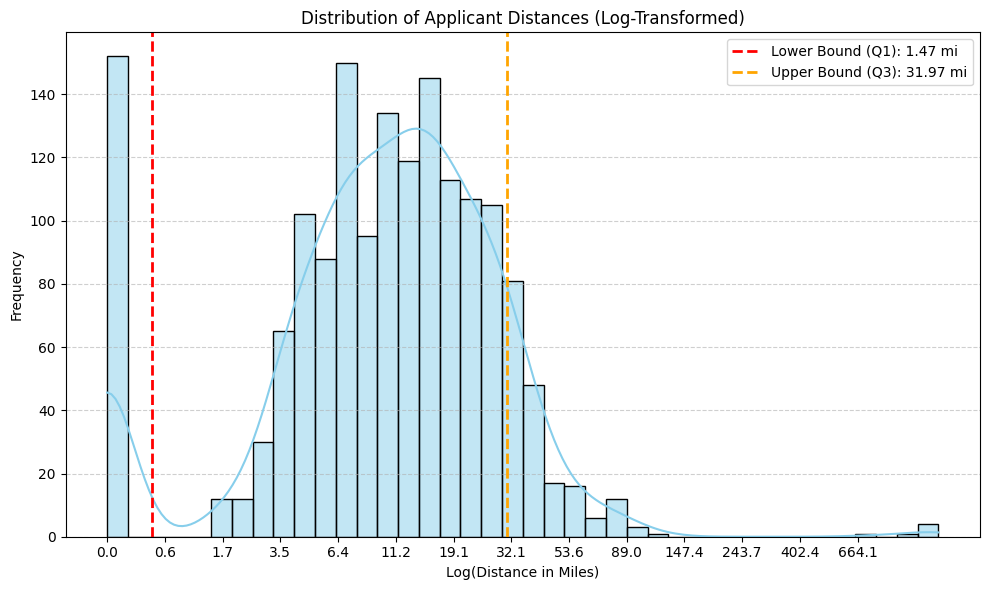

In [10]:
upper_T_log_visual = 5
upper_thres_log = np.expm1(T_log_visual)

lower_T_log_visual = 3.5
lower_thres_log = np.expm1(T_log_visual)

df_clean = df[df['distance_mi'] < upper_thres_log].copy()
df_clean['log_distance_mi'] = np.log(df_clean['distance_mi'])

q1 = filtered_df['distance_mi'].min()
q3 = filtered_df['distance_mi'].max()

plt.figure(figsize=(10, 6))
sns.histplot(df['log_distance_mi'], bins=40, kde=True, color='skyblue', edgecolor='black')

log_ticks = np.arange(0, 7, 0.5)
mile_labels = np.expm1(log_ticks)
formatted_labels = [f'{m:.1f}' for m in mile_labels]
plt.xticks(log_ticks, formatted_labels, rotation=0, ha='center')

plt.axvline(np.log(q1), color='red', linestyle='--', linewidth=2, label=f'Lower Bound (Q1): {q1:.2f} mi')
plt.axvline(np.log(q3), color='orange', linestyle='--', linewidth=2, label=f'Upper Bound (Q3): {q3:.2f} mi')

plt.title('Distribution of Applicant Distances (Log-Transformed)')
plt.xlabel('Log(Distance in Miles)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

print(f"Histogram created. Q1: {q1:.2f}, Q3: {q3:.2f}")

about 80% of applicants fall between 1.47 miles and 31.97 miles

In [11]:
filtered_df = df[
    (df['distance_mi'] < thres_log)
].copy()

filtered_df['distance_mi'].describe()

,distance_mi
count,1469.000000
mean,11.461867
std,8.291065
min,0.000000
25%,4.939624
50%,9.992987
75%,16.641525
max,31.970441


In [12]:
print(len(filtered_df)/len(df)) # 90.73%

0.907350216182829


about 90% of applicants have movement distance smaller than 31.97 miles.

# Demographic Movement Comparison

To answer the base Question 1, we analyzed the demographic distribution by distance movement.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1619 entries, 0 to 1618
Data columns (total 50 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   id_number                                 1619 non-null   int64  
 1   submission_date                           1619 non-null   object 
 2   age                                       1619 non-null   int64  
 3   disability                                1619 non-null   int64  
 4   chapa_races                               1619 non-null   object 
 5   census_races                              1619 non-null   object 
 6   current_residence_town_city               1619 non-null   object 
 7   current_residence_state                   1619 non-null   object 
 8   current_residence_zip                     1619 non-null   int64  
 9   application_source                        1619 non-null   object 
 10  hh_size                             

Distance Comparison - Race/ethnicity

In [14]:
df_clean = df[df['distance_mi'] < thres_log].copy()

race_cols = [
    'race_white',
    'race_black_or_african_american',
    'race_hispanic_or_latino',
    'race_asian',
    'race_middle_eastern_or_north_african',
    'race_american_indian_or_alaska_native',
    'race_native_hawaiian_or_pacific_islander'
]

race_label_map = {
    'race_white': 'White',
    'race_black_or_african_american': 'Black or African American',
    'race_hispanic_or_latino': 'Hispanic or Latino',
    'race_asian': 'Asian',
    'race_middle_eastern_or_north_african': 'Middle Eastern or North African',
    'race_american_indian_or_alaska_native': 'Native American or Alaskan Native',
    'race_native_hawaiian_or_pacific_islander': 'Native Hawaiian or Pacific Islander'
}

In [15]:
df_race = []
for col in race_cols:
  df_temp = df_clean[df_clean[col] == 1].copy()
  df_temp['Race Category'] = race_label_map[col]
  df_race.append(df_temp[['distance_mi', 'Race Category']])

df_race = pd.concat(df_race)
mean_distance_order = df_race.groupby('Race Category')['distance_mi'].mean().sort_values(ascending=False).index

In [16]:
df_race['Race Category'].value_counts()

,count
Race Category,
White,796
Black or African American,229
Asian,213
Hispanic or Latino,210
Native Hawaiian or Pacific Islander,84
Middle Eastern or North African,41
Native American or Alaskan Native,7


/tmp/ipython-input-2187169189.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='distance_mi', y='Race Category', data=df_race, order=mean_distance_order, palette="viridis")


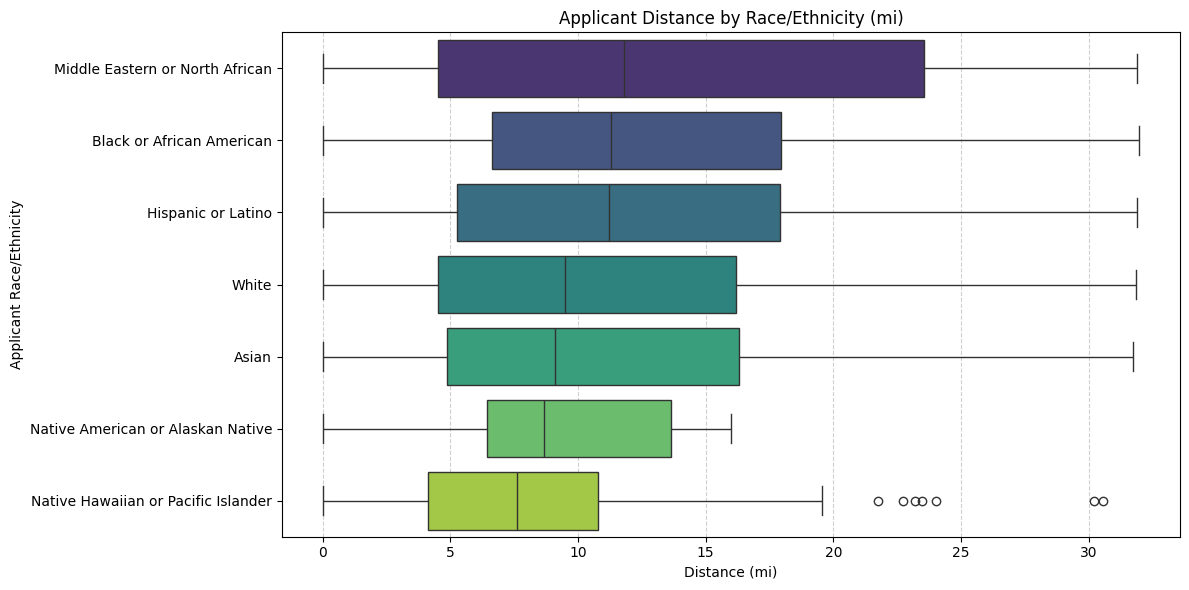

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='distance_mi', y='Race Category', data=df_race, order=mean_distance_order, palette="viridis")
plt.title('Applicant Distance by Race/Ethnicity (mi)')
plt.xlabel('Distance (mi)')
plt.ylabel('Applicant Race/Ethnicity')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

Middle Eastern/North African, Black/African, and Hispanic/Latino applicants consistently exhibit higher mean travel distances compared to White applicants.

In [18]:
# HOC vs. White
non_white_cols = [
    'race_american_indian_or_alaska_native',
    'race_asian',
    'race_black_or_african_american',
    'race_hispanic_or_latino',
    'race_middle_eastern_or_north_african',
    'race_native_hawaiian_or_pacific_islander'
]

df_clean = df[df['distance_mi'] < thres_log].copy()
df_clean['non_white_sum'] = df_clean[non_white_cols].sum(axis=1)

def classifiy_hoc_vs_white(row):
  if row['non_white_sum'] > 0:
    return 'Households of Color (HOC)'
  elif row['race_white'] == 1 and row['race_count'] == 1:
    return 'White'
  else:
    return 'Other/Unknown'

df_clean['race_hoc_vs_white'] = df_clean.apply(classifiy_hoc_vs_white, axis=1)
df_plot_hoc = df_clean[df_clean['race_hoc_vs_white'] != 'Other/Unknown'].copy()
mean_hoc_order = df_plot_hoc.groupby('race_hoc_vs_white')['distance_mi'].mean().sort_values(ascending=False).index

/tmp/ipython-input-3664864698.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='distance_mi', y='race_hoc_vs_white', data=df_plot_hoc, order=mean_hoc_order, palette='coolwarm')


Mean Distance (HOC): 12.04 miles
Mean Distance (White): 10.91 miles


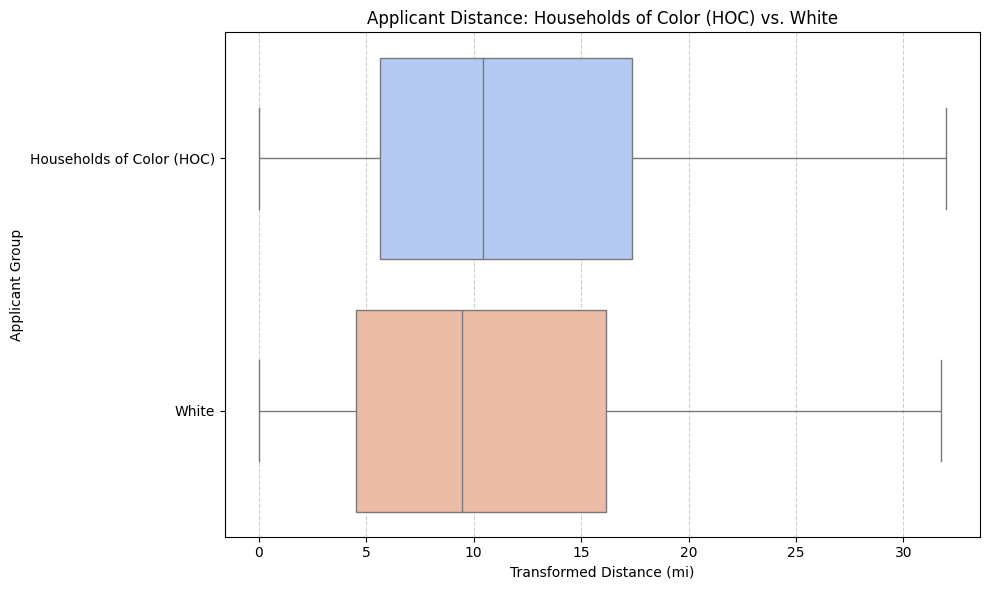

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='distance_mi', y='race_hoc_vs_white', data=df_plot_hoc, order=mean_hoc_order, palette='coolwarm')
plt.title('Applicant Distance: Households of Color (HOC) vs. White')
plt.xlabel('Transformed Distance (mi)')
plt.ylabel('Applicant Group')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

hoc_mean = df_plot_hoc[df_plot_hoc['race_hoc_vs_white'] == 'Households of Color (HOC)']['distance_mi'].mean()
white_mean = df_plot_hoc[df_plot_hoc['race_hoc_vs_white'] == 'White']['distance_mi'].mean()

print(f"Mean Distance (HOC): {hoc_mean:.2f} miles")
print(f"Mean Distance (White): {white_mean:.2f} miles")

Comparing the distance distributions between Households of Color (HOC) and White only applicants.
According to this plot, the mean travel distance for the HOC is 12.04 miles, which is notably longer than the 10.91 miles for White Only applicants.
And the mean travel distance of HOC is larger than the overall group mean (11.46 miles).

Distance Comparison - Household Type

In [20]:
df['hh_type'].value_counts()

,count
hh_type,
Single person,630
"Married/partners/couple, no dependents",410
Single parent,274
Unknown,264
"More than one related adults, with dependents",17
Other,13
"More than one related adults, no dependents",9
"Married/partners/couple, with dependents",2


In [21]:
df_clean = df[df['distance_mi'] < thres_log].copy()

def simplify_hh_type(hh_type):
  if hh_type == 'Single person':
    return 'Single person'
  elif hh_type == 'Single parent':
    return 'Single parent'
  elif 'Married/partners/couple' in hh_type or 'More than one related adult' in hh_type:
    return 'Couple/Multiple Adults'
  else:
    return 'Other/Unknown'

df_clean['hh_type_simplified'] = df_clean['hh_type'].apply(simplify_hh_type)
print(df_clean['hh_type_simplified'].value_counts())

hh_type_simplified
Single person             567
Couple/Multiple Adults    393
Other/Unknown             255
Single parent             254
Name: count, dtype: int64


/tmp/ipython-input-3472372662.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='distance_mi', y='hh_type_simplified', data=df_plot_hh, palette='plasma')


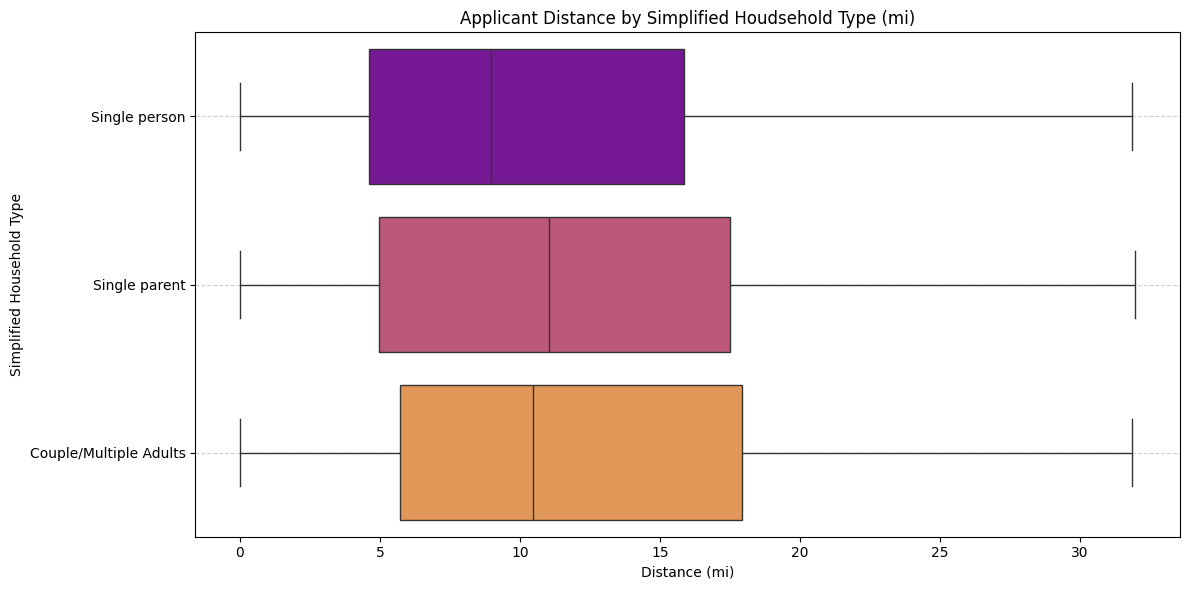

In [22]:
df_plot_hh = df_clean[df_clean['hh_type_simplified'] != 'Other/Unknown'].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(x='distance_mi', y='hh_type_simplified', data=df_plot_hh, palette='plasma')
plt.title('Applicant Distance by Simplified Houdsehold Type (mi)')
plt.xlabel('Distance (mi)')
plt.ylabel('Simplified Household Type')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

Single Parents demonstrated the widest search radius, whereas Single Persons exhibited the narrowest.

Distance Comparison - Age (grouping by age restriction range)

In [23]:
df_clean = df[df['distance_mi'] < thres_log].copy()

bins = [18, 24, 34, 44, 54, 90]
labels = ['18-24', '25-34', '35-44', '45-54', '55+']
df_clean['age_bracket'] = pd.cut(df_clean['age'], bins=bins, labels=labels, right=True, include_lowest=True)

df_clean = df_clean.dropna(subset=['age_bracket'])

/tmp/ipython-input-1799876351.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_bracket', y='distance_mi', data=df_clean, palette="Set2")
/tmp/ipython-input-1799876351.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_clean.groupby('age_bracket')['distance_mi'].agg(['mean', 'median', 'count'])


Summary Statistics (Distance in Miles):
                  mean     median  count
age_bracket                             
18-24        11.096674   8.716271     87
25-34        11.001484   9.875069    485
35-44        12.471963  11.165827    416
45-54        11.442531   8.835341    184
55+          10.917812   9.243589    297


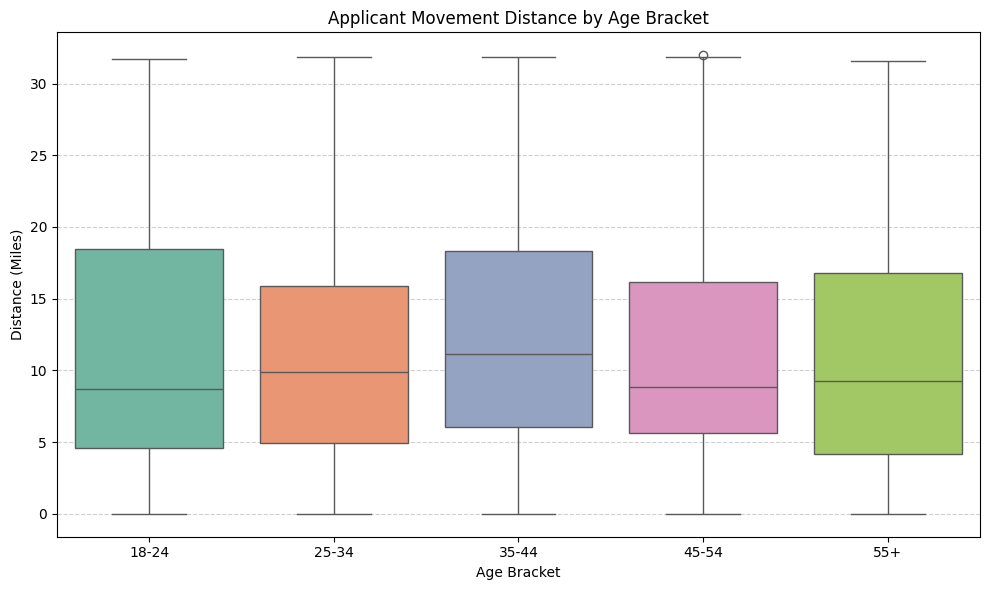

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='age_bracket', y='distance_mi', data=df_clean, palette="Set2")

plt.title('Applicant Movement Distance by Age Bracket')
plt.xlabel('Age Bracket')
plt.ylabel('Distance (Miles)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

summary = df_clean.groupby('age_bracket')['distance_mi'].agg(['mean', 'median', 'count'])
print("Summary Statistics (Distance in Miles):")
print(summary)

plt.tight_layout()

Age bracket in 35-44 has largest distance movement with 11.16 miles. But this mean value is smaller than the overall mean value (11.46 miles). So there are no big difference between age distribution.

# Targeting Effectiveness Analysis

In [25]:
df_clean = df[df['distance_mi'] < thres_log].copy()
print(df_clean['application_source'].value_counts())

application_source
MyMassHome                     469
Zillow/Trulia/Other Website    405
Real Estate Agent              335
Friend/Word of Mouth           103
Unknown                         81
City of Boston Metrolist        32
Social Media                    18
CHAPA                           17
Local Community                  9
Name: count, dtype: int64


In [26]:
major_sources = [
    'MyMassHome',
    'Zillow/Trulia/Other Website',
    'Real Estate Agent',
    'Friend/Word of Mouth',
    'CHAPA'
]

def simplify_source(source):
  if source in major_sources:
    return source
  else:
    return 'Other/Unknown'

df_clean['source_simplified'] = df_clean['application_source'].apply(simplify_source)
print(df_clean['source_simplified'].value_counts())

source_simplified
MyMassHome                     469
Zillow/Trulia/Other Website    405
Real Estate Agent              335
Other/Unknown                  140
Friend/Word of Mouth           103
CHAPA                           17
Name: count, dtype: int64


/tmp/ipython-input-2601151229.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='distance_mi', y='source_simplified', data=df_plot_source, order=mean_source_order, palette="tab10")


source_simplified
MyMassHome                     13.244341
CHAPA                          11.069589
Real Estate Agent              11.055605
Zillow/Trulia/Other Website    10.757396
Friend/Word of Mouth            7.652140
Name: distance_mi, dtype: float64


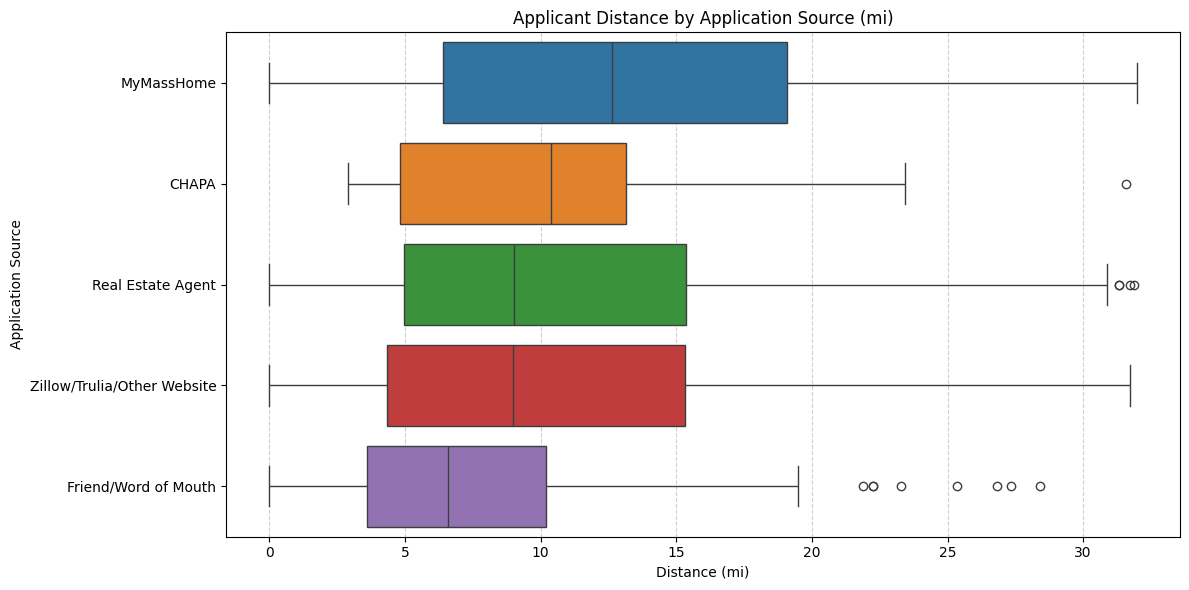

In [27]:
df_plot_source = df_clean[df_clean['source_simplified'] != 'Other/Unknown'].copy()
mean_source_order = df_plot_source.groupby('source_simplified')['distance_mi'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(x='distance_mi', y='source_simplified', data=df_plot_source, order=mean_source_order, palette="tab10")
plt.title('Applicant Distance by Application Source (mi)')
plt.xlabel('Distance (mi)')
plt.ylabel('Application Source')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

source_means = df_plot_source.groupby('source_simplified')['distance_mi'].mean().sort_values(ascending=False)
print(source_means)

Digital platforms like MyMassHome and Metrolist attracted applicants with the longest travel distance, while Word of Mouth was associated with the shortest travel distances.

# Local vs. Distant Demographic

To answer the base Question 1-(b), we analyzed the demographic features by comparing Local and Distant applicants.

We divided Local and Distant applicant using our lower (<= 1.47 miles) and upper (>= 31.97 miles) threshold. The reason why we used this threshold is that we are analyzing the characteristics of groups exhibiting extreme movement patterns. Therefore, rather than using the other methods we considered before when we were doing EDA (whether moved to other town/city, whether the movement distance is larger than mean town diameter), setting the criteria at distance_mi <= 1.47 and >= 31.97 is the most effective way to sharpen the focus of our analysis and isolate the effects of distance on specific demographic cohorts.

In [28]:
top_5_towns_new = df['property_town_city'].value_counts().head(5)
print(top_5_towns_new)

property_town_city
North Andover    139
Tyngsborough      89
Ayer              81
Canton            78
Braintree         77
Name: count, dtype: int64


In [29]:
df_clean = df.copy()

non_white_cols = [
    'race_black_or_african_american',
    'race_hispanic_or_latino',
    'race_asian',
    'race_middle_eastern_or_north_african',
    'race_american_indian_or_alaska_native',
    'race_native_hawaiian_or_pacific_islander'
]
df_clean['non_white_sum'] = df_clean[non_white_cols].sum(axis=1)

def classify_hoc_vs_white(row):
    if row['non_white_sum'] > 0:
        return 'Households of Color (HOC)'
    elif row['race_white'] == 1 and row['race_count'] == 1:
        return 'White'
    else:
        return 'Other/Unknown'

df_clean['race_hoc_vs_white'] = df_clean.apply(classify_hoc_vs_white, axis=1)

In [30]:
local_thres = 1.47
distant_thres = 31.97

def classify_distance_new(distance):
    if distance <= local_thres:
        return 'Local'
    elif distance >= distant_thres:
        return 'Distant'
    else:
        return 'Intermediate'

df_clean['distance_group'] = df_clean['distance_mi'].apply(classify_distance_new)

df_plot = df_clean[
    (df_clean['distance_group'] != 'Intermediate') &
    (df_clean['race_hoc_vs_white'] != 'Other/Unknown')
].copy()

In [31]:
new_top_5_list = ['North Andover', 'Tyngsborough', 'Ayer', 'Canton', 'Braintree']
df_plot_top5 = df_plot[df_plot['property_town_city'].isin(new_top_5_list)].copy()

distribution = df_plot_top5.groupby(['property_town_city', 'distance_group', 'race_hoc_vs_white']).size().reset_index(name='count')
total_per_group = distribution.groupby(['property_town_city', 'distance_group'])['count'].sum().reset_index(name='total')
df_merged = pd.merge(distribution, total_per_group, on=['property_town_city', 'distance_group'])
df_merged['percentage'] = (df_merged['count'] / df_merged['total']) * 100

plot_data = df_merged.pivot_table(
    index=['property_town_city', 'distance_group'],
    columns='race_hoc_vs_white',
    values='percentage'
).reset_index()
plot_data.columns.name = None
plot_data = plot_data.fillna(0)

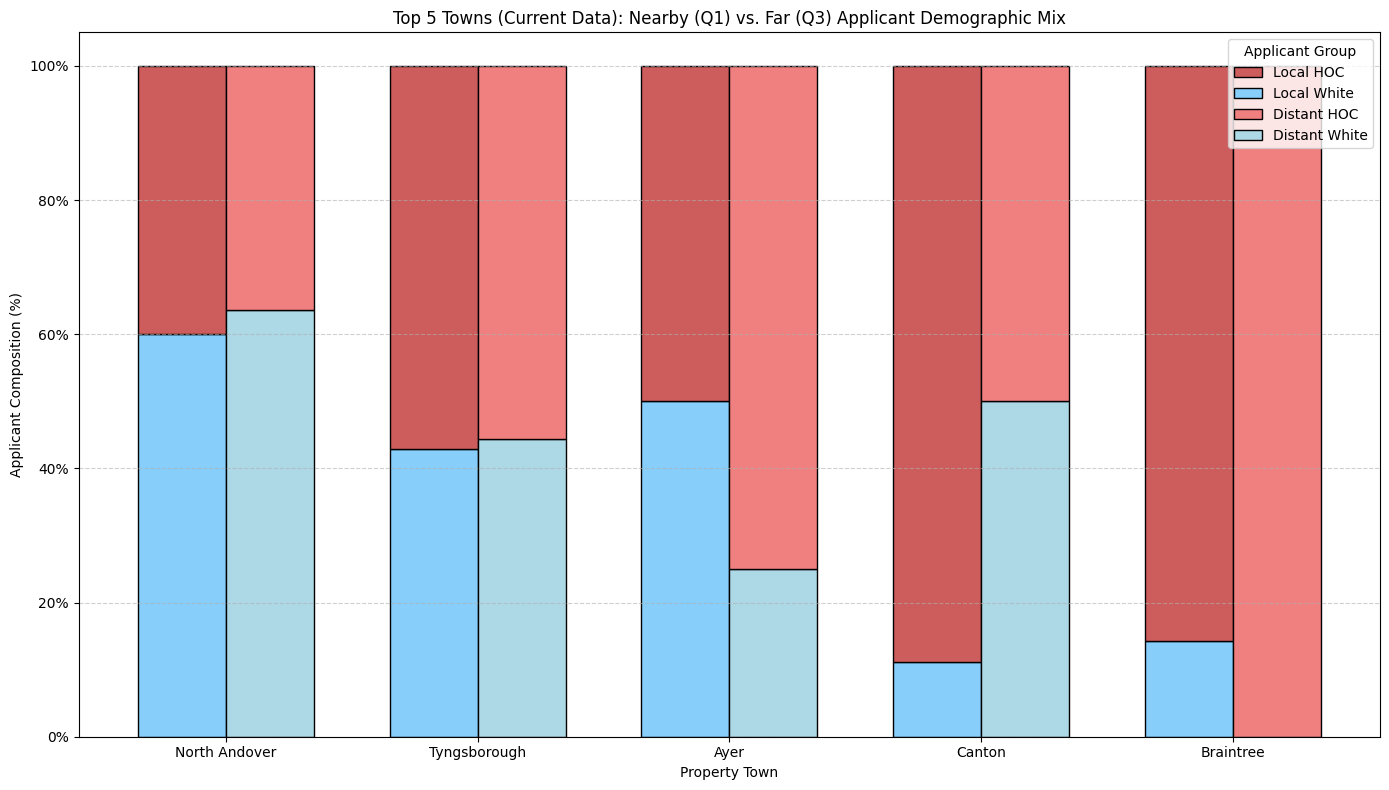

In [32]:
fig, ax = plt.subplots(figsize=(14, 8))
width = 0.35
x = np.arange(len(new_top_5_list))
x_mapping = {town: i for i, town in enumerate(new_top_5_list)}

color_map_hoc_nearby = 'indianred'
color_map_white_nearby = 'lightskyblue'
color_map_hoc_far = 'lightcoral'
color_map_white_far = 'lightblue'

for town in new_top_5_list:
    town_data = plot_data[plot_data['property_town_city'] == town]
    x_pos = x_mapping[town]

    for j, distance_group in enumerate(['Local', 'Distant']):
        group_data = town_data[town_data['distance_group'] == distance_group]
        if group_data.empty: continue

        offset = -width/2 if distance_group == 'Local' else width/2

        white_pct = group_data['White'].iloc[0]
        hoc_pct = group_data['Households of Color (HOC)'].iloc[0]

        white_color = color_map_white_nearby if distance_group == 'Local' else color_map_white_far
        hoc_color = color_map_hoc_nearby if distance_group == 'Local' else color_map_hoc_far

        ax.bar(x_pos + offset, white_pct, width, color=white_color, edgecolor='black', label='_nolegend_')
        ax.bar(x_pos + offset, hoc_pct, width, bottom=white_pct, color=hoc_color, edgecolor='black', label='_nolegend_')

legend_handles = [
    Patch(facecolor=color_map_hoc_nearby, edgecolor='black', label='Local HOC'),
    Patch(facecolor=color_map_white_nearby, edgecolor='black', label='Local White'),
    Patch(facecolor=color_map_hoc_far, edgecolor='black', label='Distant HOC'),
    Patch(facecolor=color_map_white_far, edgecolor='black', label='Distant White')
]

ax.set_ylabel('Applicant Composition (%)')
ax.set_xlabel('Property Town')
ax.set_title('Top 5 Towns (Current Data): Nearby (Q1) vs. Far (Q3) Applicant Demographic Mix')
ax.set_xticks(x)
ax.set_xticklabels(new_top_5_list)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(handles=legend_handles, title='Applicant Group', loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

There exists a clear regional disparities.
In HOC-dense areas like Canton, local demand sustains HOC access. However, in White-dominated suburbs like North Andover, the local market favors White residents.

# Local vs. Distant (original town/city difference)

Since our Client's first request about Local vs. Distant was based on wheter the applicant moved to another town/city compared to their current residences, we also did the analyzation of demographic features by distance movement.

In [33]:
print(df['local_applicant_town'].value_counts())

local_applicant_town
0.0    1464
1.0     155
Name: count, dtype: int64


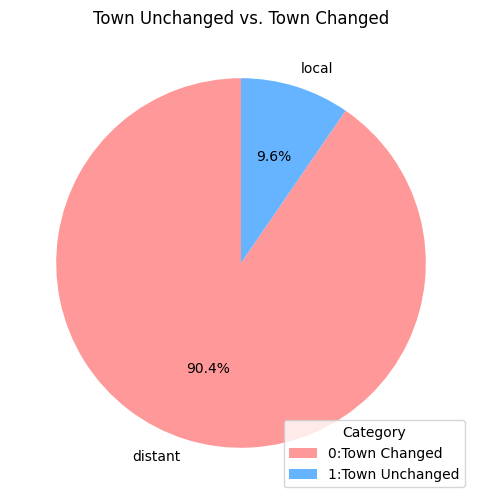

In [34]:
town_counts = df['local_applicant_town'].value_counts()
labels_town = ['distant', 'local']
colors_town = ['#ff9999', '#66b3ff']

plt.figure(figsize=(8, 6))

plt.plot()
plt.pie(town_counts, labels=labels_town, colors=colors_town, autopct='%1.1f%%', startangle=90)
plt.title('Town Unchanged vs. Town Changed')
plt.legend(title='Category', loc='lower right', labels=['0:Town Changed', '1:Town Unchanged'])

Less than 10% of applicants applied to the same property.

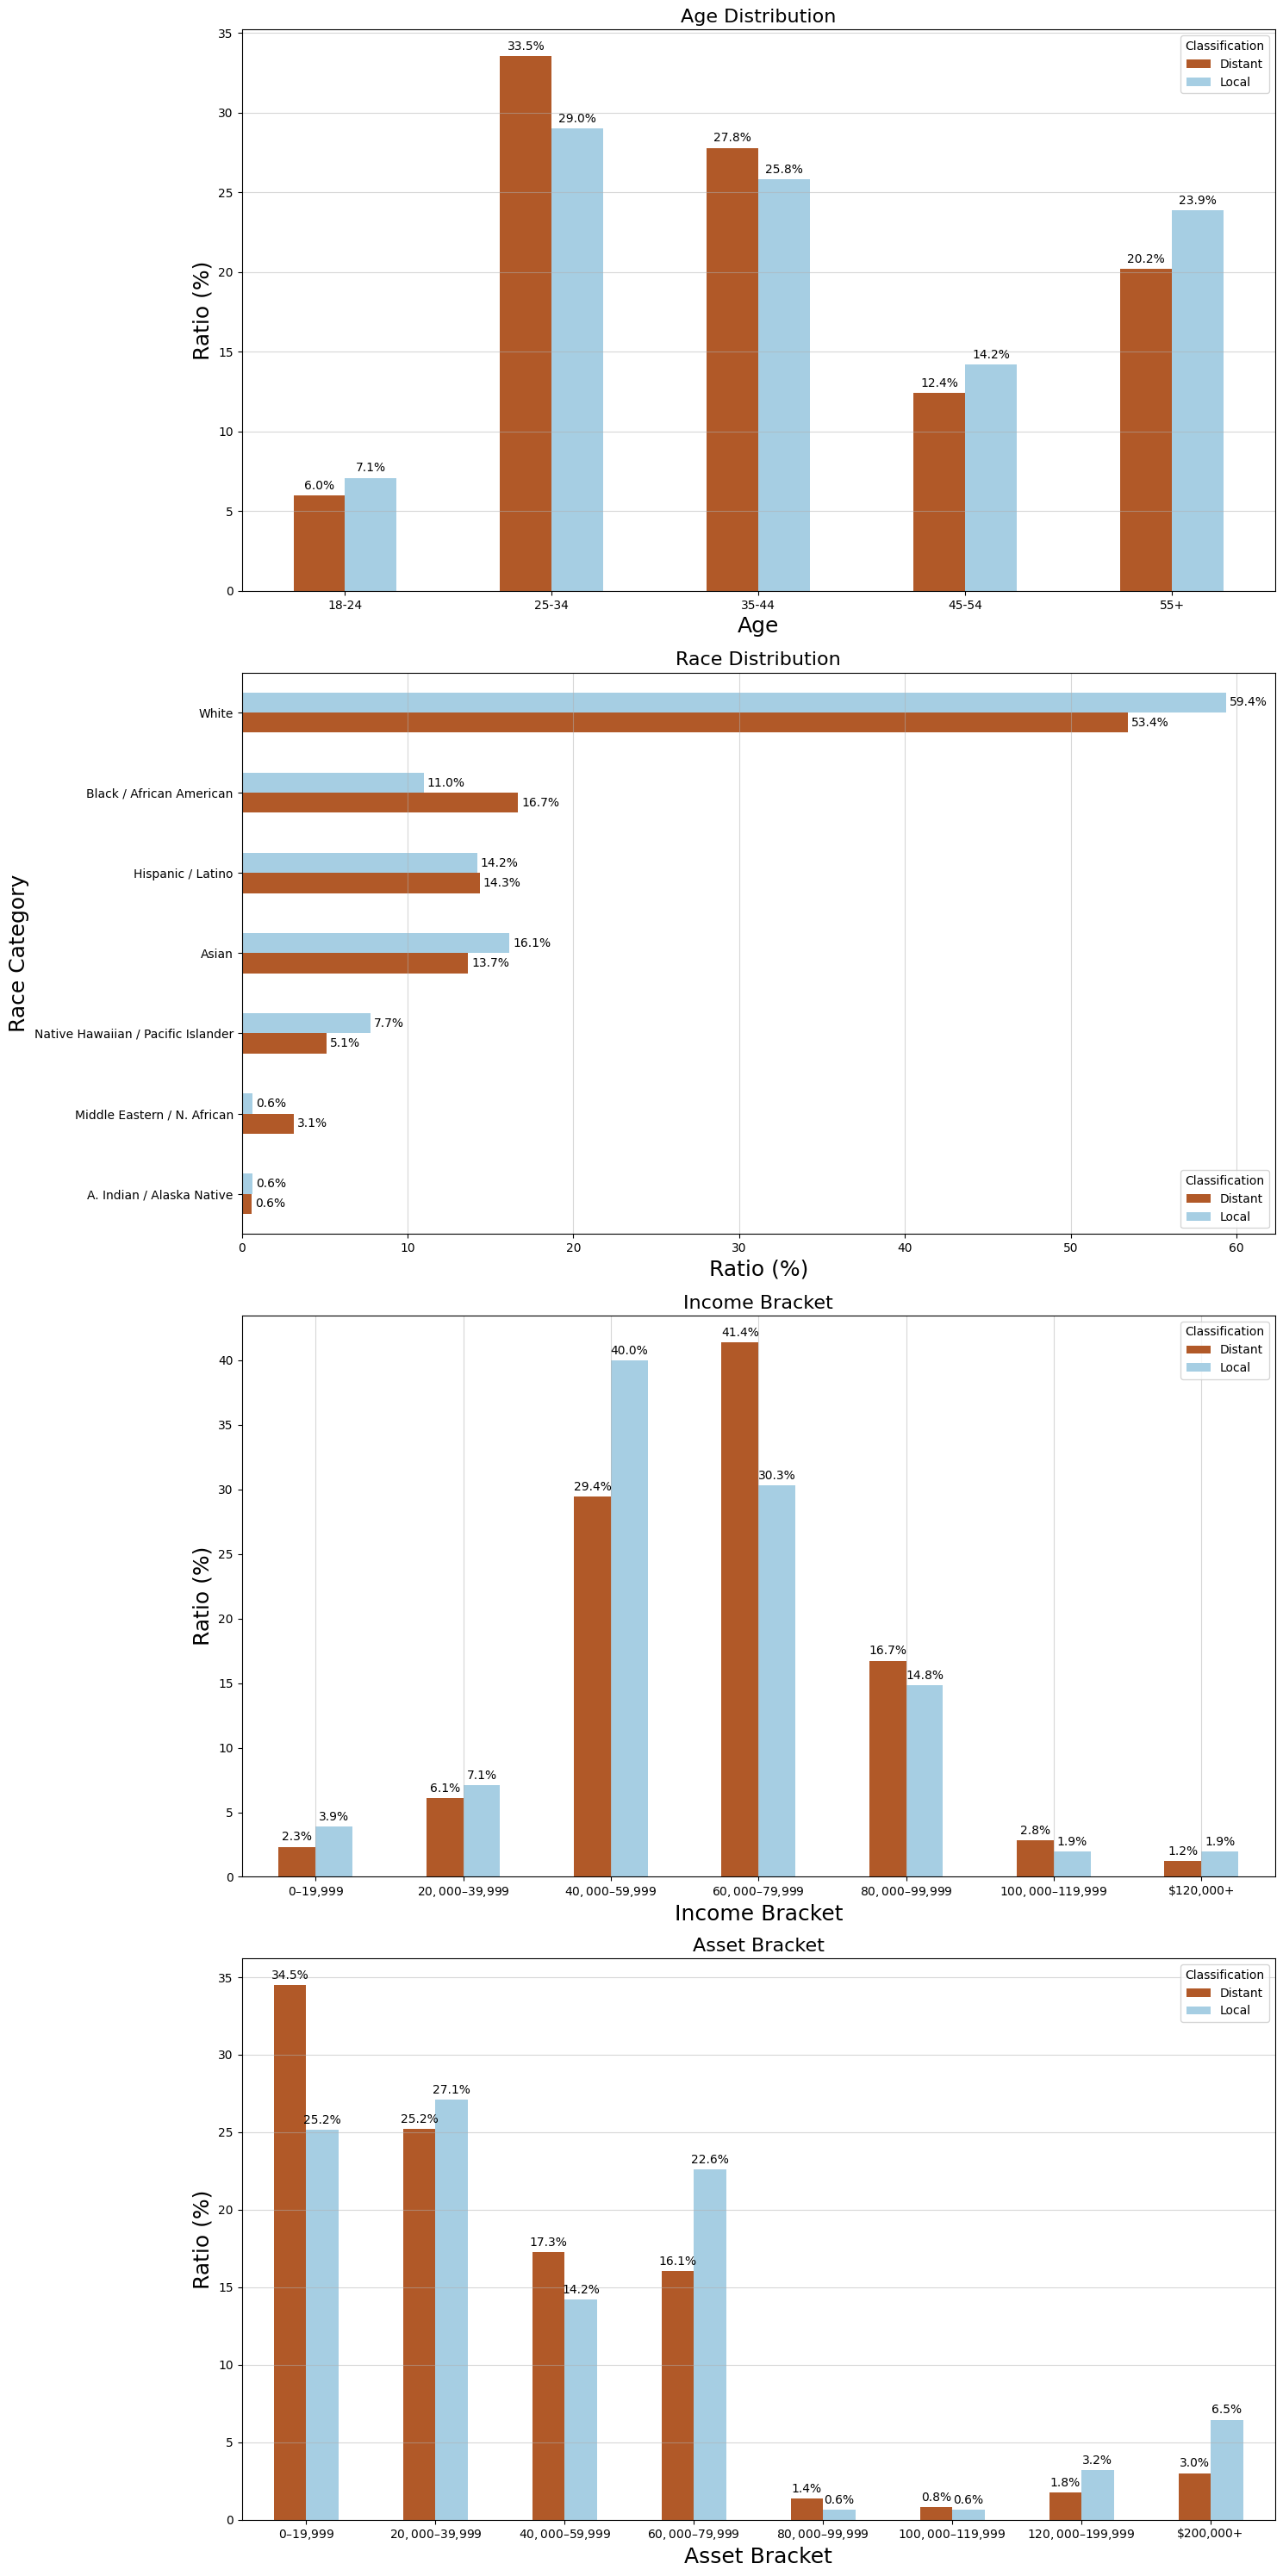

In [35]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 30))
plt.subplots_adjust(hspace=0.6)
my_colors = ['#b15928', '#a6cee3']

# 1. Age Plot (Vertical)
bins = [18, 24, 34, 44, 54, 90]
labels = ['18-24', '25-34', '35-44', '45-54', '55+']
age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
df['age_bracket'] = pd.cut(df['age'], bins=bins, labels=labels, right=True, include_lowest=True)

ct_counts = pd.crosstab(df['local_applicant_town'], df['age_bracket'])
ct_counts = ct_counts.reindex(columns=age_order, fill_value=0)
ct_proportion = ct_counts.div(ct_counts.sum(axis=1), axis=0) * 100
ct_proportion.index = ['Distant', 'Local']
ct_proportion.T.plot(kind='bar', ax=axes[0], color=my_colors)

axes[0].set_title('Age Distribution', fontsize=16)
axes[0].set_xlabel('Age', fontsize=18)
axes[0].set_ylabel('Ratio (%)', fontsize=18)
axes[0].legend(title='Classification', loc='upper right')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.5)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='edge', padding=3)

# 2. Race Plot (Horizontal)
race_cols = [
    'race_american_indian_or_alaska_native',
    'race_asian',
    'race_black_or_african_american',
    'race_hispanic_or_latino',
    'race_middle_eastern_or_north_african',
    'race_native_hawaiian_or_pacific_islander',
    'race_white'
]

race_labels = {
    'race_american_indian_or_alaska_native': 'A. Indian / Alaska Native',
    'race_asian': 'Asian',
    'race_black_or_african_american': 'Black / African American',
    'race_hispanic_or_latino': 'Hispanic / Latino',
    'race_middle_eastern_or_north_african': 'Middle Eastern / N. African',
    'race_native_hawaiian_or_pacific_islander': 'Native Hawaiian / Pacific Islander',
    'race_white': 'White'
}

local_count = len(df[df['local_applicant_town'] == 1])
distant_count = len(df[df['local_applicant_town'] == 0])

race_proportions = {}
for col in race_cols:
    local_sum = df[df['local_applicant_town'] == 1][col].sum()
    distant_sum = df[df['local_applicant_town'] == 0][col].sum()

    race_proportions[race_labels[col]] = {
        'Distant': (distant_sum / distant_count) * 100 if distant_count > 0 else 0,
        'Local': (local_sum / local_count) * 100 if local_count > 0 else 0
    }

df_proportions = pd.DataFrame(race_proportions).T
df_proportions = df_proportions[['Distant', 'Local']]
df_proportions = df_proportions.sort_values(by='Distant', ascending=True)

df_proportions.plot(kind='barh', ax=axes[1], color=my_colors)

axes[1].set_title('Race Distribution', fontsize=16)
axes[1].set_xlabel('Ratio (%)', fontsize=18)
axes[1].set_ylabel('Race Category', fontsize=18)
axes[1].legend(title='Classification', loc='lower right')
axes[1].grid(axis='x', alpha=0.5)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='edge', padding=3)

method = 'local_applicant_town'

# 3. Income Bracket Plot (Horizontal)
income_order = [
   '$0–$19,999',
    '$20,000–$39,999',
    '$40,000–$59,999',
    '$60,000–$79,999',
    '$80,000–$99,999',
    '$100,000–$119,999',
    '$120,000+'
]
ct_counts_inc = pd.crosstab(df[method], df['income_bracket'])
ct_proportion_inc = ct_counts_inc.div(ct_counts_inc.sum(axis=1), axis=0) * 100
ct_proportion_inc = ct_proportion_inc.reindex(columns=income_order, fill_value=0)
ct_proportion_inc.index = ['Distant', 'Local']
ct_proportion_inc.T.plot(kind='bar', ax=axes[2], color=my_colors, rot=0)

axes[2].set_title('Income Bracket', fontsize=16)
axes[2].set_ylabel('Ratio (%)', fontsize=18)
axes[2].set_xlabel('Income Bracket', fontsize=18)
axes[2].legend(title='Classification', loc='upper right')
axes[2].grid(axis='x', alpha=0.5)

for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.1f%%', label_type='edge', padding=3)

# 4. Asset Bracket Plot (Horizontal)
asset_order = [
    '$0–$19,999',
    '$20,000–$39,999',
    '$40,000–$59,999',
    '$60,000–$79,999',
    '$80,000–$99,999',
    '$100,000–$119,999',
    '$120,000–$199,999',
    '$200,000+'
]
ct_counts_asset = pd.crosstab(df[method], df['asset_bracket'])
ct_proportion_asset = ct_counts_asset.div(ct_counts_asset.sum(axis=1), axis=0) * 100
ct_proportion_asset = ct_proportion_asset.reindex(columns=asset_order, fill_value=0)
ct_proportion_asset.index = ['Distant', 'Local']
ct_proportion_asset.T.plot(kind='bar', ax=axes[3], color=my_colors, rot=0)

axes[3].set_title('Asset Bracket', fontsize=16)
axes[3].set_ylabel('Ratio (%)', fontsize=18)
axes[3].set_xlabel('Asset Bracket', fontsize=18)
axes[3].legend(title='Classification', loc='upper right')
axes[3].grid(axis='y', alpha=0.5)
axes[3].tick_params(axis='x', rotation=0)

for container in axes[3].containers:
    axes[3].bar_label(container, fmt='%.1f%%', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

1. Age Distribution: Applicants aged 31–60 tend to migrate within their local living areas, whereas those aged 18–30 and over 61 exhibit super-regional migration patterns. Specifically, applicants in the 31–60 bracket (characterized by prime working years and child-rearing) show an average migration distance of approximately 43–44 miles. This is roughly one-third of the average distance observed in the 18–30 and 61+ groups, which exceeds 100 miles.

2. Race Distribution: There is a notable difference in the ranking of racial groups between Local and Distant applicants. While White applicants remain the dominant majority in both, the second and fourth rankings are swapped.
- Asian applicants rank 2nd in 'Local' but 4th in 'Distant', indicating a stronger tendency to seek housing within their local area compared to other races.
- Conversely, Black/African American applicants rank 4th in 'Local' but rise to 2nd in 'Distant', suggesting a relatively higher proportion of Black applicants seeking homeownership opportunities through migration to external regions.

3. Income: The income levels of 'Distant' are generally higher than those of 'Local'. Specifically, 41.4% of Distant applicants fall into the $60,000–$79,999 bracket. This is approximately 11% higher than 'Local', suggesting that the influx of population from other regions consists primarily of middle-to-high income earners.

4. Asset: In contrast to income, 'Local' demonstrates much more robust asset holdings, while 'Distant' has a higher proportion of asset-poor applicants. Notably, 34.5% of 'Distant' falls into the lowest asset bracket ($0–$19,999). This figure is about 10% higher than that of 'Local', implying that applicants from other regions lack immediate access to liquid assets.

# Map Visualization

To provide a clearer spatial context, we visualized the actual locations of applicants on a geographic map.

In [36]:
!pip install geopandas matplotlib

In [37]:
!pip install contextily

In [38]:
import geopandas as gpd
import contextily as cx

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/40B_zip_long_lat.csv')

current_map_data = df.groupby(['current_residence_town_city', 'current_residence_state']).agg(
    applicant_count = ('id_number', 'count'),
    latitude_avg = ('current_lat', 'mean'),
    longitude_avg=('current_lon', 'mean')
).reset_index()

current_map_data.rename(columns = {
    'current_residence_town_city': 'town/city',
    'current_residence_state': 'state',
    'applicant_count': 'applicant count',
    'latitude_avg': 'latitude',
    'longitude_avg': 'longitude'
}, inplace=True)

current_map_data['town/city'] = current_map_data['town/city'].str.upper()
print(current_map_data.head())

gdf_towns = gpd.read_file('/content/drive/MyDrive/Colab Notebooks/TOWNSSURVEY_POLYM_GENCOAST.shp')
gdf_towns['TOWN_KEY'] = gdf_towns['TOWN'].str.upper()

current_map_data['TOWN_KEY'] = current_map_data['town/city'].str.upper()
current_merged_data = gdf_towns.merge(
    current_map_data[['TOWN_KEY', 'applicant count']],
    on='TOWN_KEY',
    how='left'
)

print(current_merged_data[['TOWN', 'applicant count']].head())

  town/city state  applicant count  latitude  longitude
0  ABINGTON    MA                2     42.11     -70.95
1     ACTON    MA                2     42.48     -71.46
2  ACUSHNET    MA                2     41.68     -70.90
3  AMESBURY    MA                6     42.85     -70.92
4   AMHERST    MA                2     42.37     -72.52
            TOWN  applicant count
0        SEEKONK              2.0
1      LAKEVILLE              1.0
2       REHOBOTH              2.0
3         CARVER              1.0
4  MIDDLEBOROUGH              2.0


In [39]:
top_10_towns = current_merged_data.sort_values(by='applicant count', ascending=False).head(10)
top_10_towns['applicant count'] = top_10_towns['applicant count'].astype(int)
print(top_10_towns[['TOWN', 'applicant count']])

          TOWN  applicant count
184  WORCESTER               78
304     LOWELL               70
193     QUINCY               46
310     BOSTON               43
267    ANDOVER               30
318    METHUEN               29
231     MALDEN               29
72    BROCKTON               28
8      TAUNTON               26
82     MILFORD               25


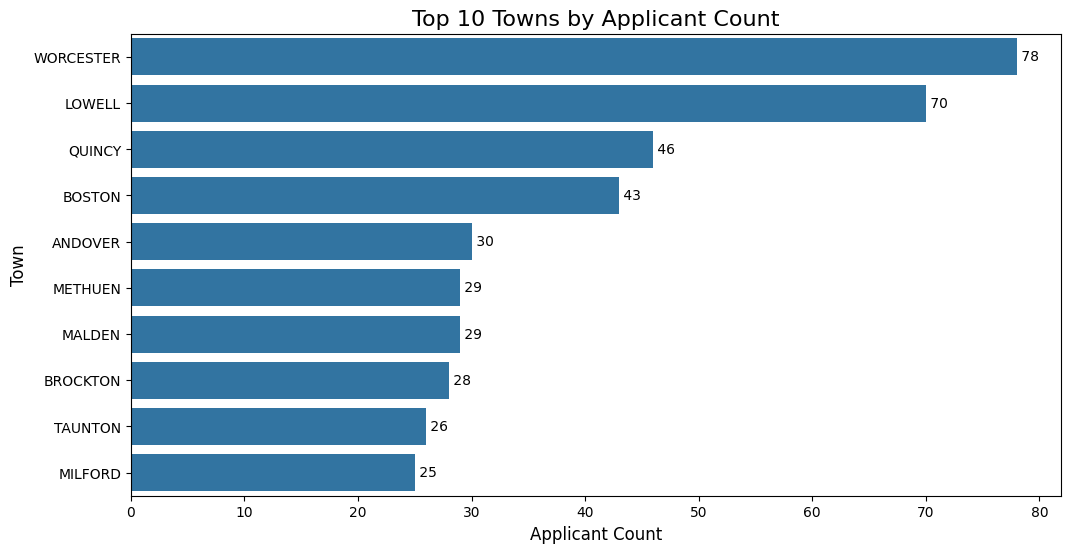

In [40]:
import seaborn as sns
plt.figure(figsize=(12, 6))

sns.barplot(
    x='applicant count',
    y='TOWN',
    data=top_10_towns,
)

plt.title('Top 10 Towns by Applicant Count', fontsize=16)
plt.xlabel('Applicant Count', fontsize=12)
plt.ylabel('Town', fontsize=12)

for index, value in enumerate(top_10_towns['applicant count']):
    plt.text(value, index, f' {value}', va='center')

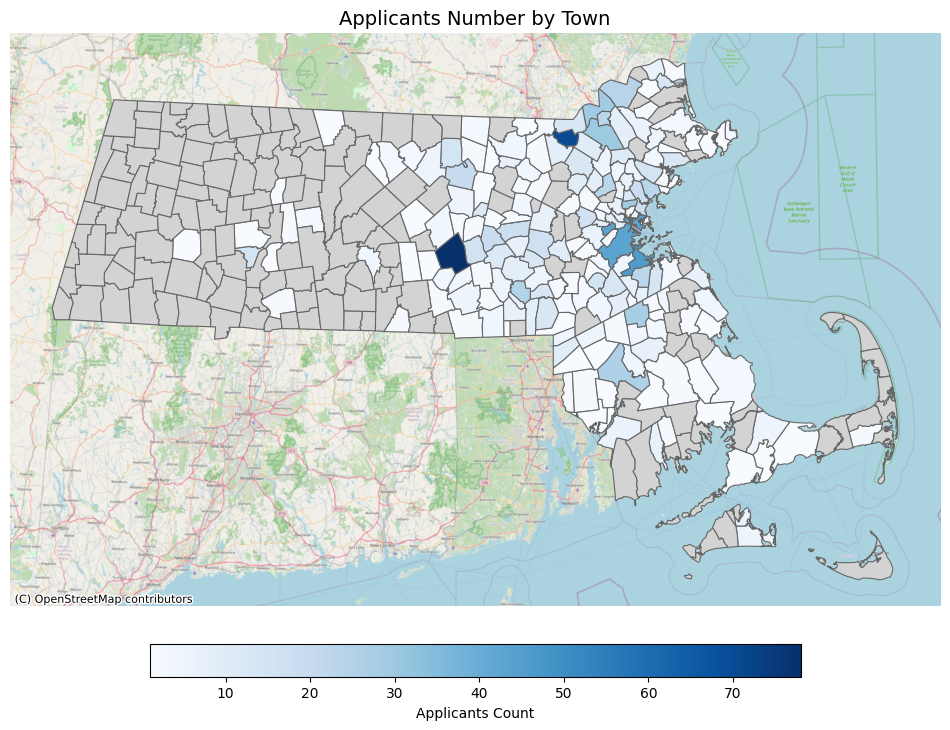

In [41]:
current_merged_data.crs = "epsg:4326"
current_merged_data_wm = current_merged_data.to_crs(epsg=26986)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

current_merged_data.plot(
    column='applicant count',
    ax=ax,
    legend=True,
    legend_kwds={'orientation': "horizontal", 'pad': 0.05, 'shrink': 0.7, 'label': "Applicants Count"},
    cmap='Blues',
    linewidth=0.8,
    edgecolor='0.4',
    missing_kwds={'color': 'lightgrey'}
)

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, zoom=10, crs=current_merged_data_wm.crs)
ax.set_title('Applicants Number by Town', fontsize=14)
ax.set_axis_off()
plt.show()

In [42]:
property_map_data = df.groupby(['property_town_city', 'property_state']).agg(
    property_count = ('property_full_address', 'nunique'),
    latitude_avg = ('property_lat', 'mean'),
    longitude_avg=('property_lon', 'mean')
).reset_index()

property_map_data.rename(columns = {
    'property_town_city': 'town/city',
    'property_state': 'state',
    'property_count': 'applicant count',
    'latitude_avg': 'latitude',
    'longitude_avg': 'longitude'
}, inplace=True)

property_map_data['town/city'] = property_map_data['town/city'].str.upper()
print(property_map_data.head())

property_map_data['TOWN_KEY'] = property_map_data['town/city'].str.upper()

property_merged_data = gdf_towns.merge(
    property_map_data[['TOWN_KEY', 'applicant count']],
    on='TOWN_KEY',
    how='left'
)

print(property_merged_data[['TOWN', 'applicant count']].head())

   town/city state  applicant count   latitude  longitude
0    ANDOVER    MA                1  42.650000 -71.140000
1       AYER    MA                2  42.560000 -71.580000
2    BEDFORD    MA                1  42.480000 -71.260000
3  BILLERICA    MA                0  42.570455 -71.287273
4  BRAINTREE    MA                3  42.200000 -71.000000
            TOWN  applicant count
0        SEEKONK              NaN
1      LAKEVILLE              1.0
2       REHOBOTH              NaN
3         CARVER              NaN
4  MIDDLEBOROUGH              NaN


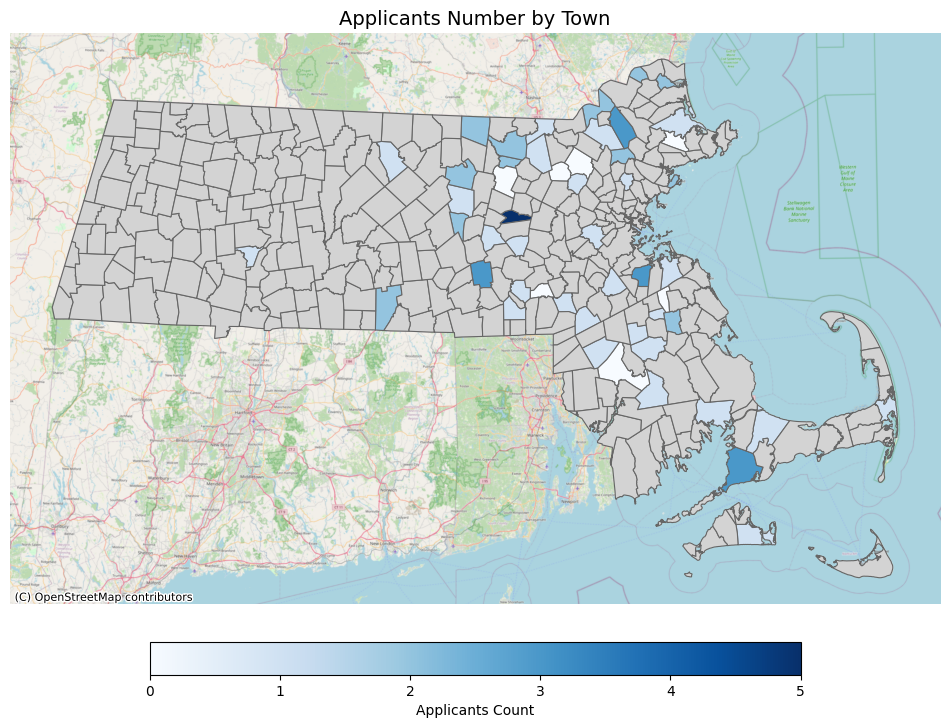

In [43]:
current_merged_data_wm = current_merged_data.to_crs(epsg=26986)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

property_merged_data.plot(
    column='applicant count',
    ax=ax,
    legend=True,
    legend_kwds={'orientation': "horizontal", 'pad': 0.05, 'shrink': 0.7, 'label': "Applicants Count"},
    cmap='Blues',
    linewidth=0.8,
    edgecolor='0.4',
    missing_kwds={'color': 'lightgrey'}
)

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, zoom=10, crs=current_merged_data_wm.crs)
ax.set_title('Applicants Number by Town', fontsize=14)
ax.set_axis_off()
plt.show()